# 第016讲 凸性与约束的几何

## 目标
给定建议点 $(3,2)$，先固定允许集合，再求欧氏距离最近的点。执行前手算，执行后分别解释可行性、距离与最优性证据。

本Notebook与 `experiment.py` 共用核心函数，不维护另一套投影实现。输入是 `data` 中的原创固定无量纲点与两条线性等式，无下载、随机训练、真实数据或付费接口。正文给一般证明，Notebook只提供有限数值核验。

直接先修：第9、11、14至15讲。KKT与对偶留到第65讲。

## 设置
从本单元目录打开Notebook，重启内核后顺序运行。脚本以自身位置查找数据。依赖为NumPy、Matplotlib、IPython与Jupyter；建议环境见 `environment.yml`。

几何核验绝对容差为1e-10；权重和容差为1e-12，接受后不重新归一化。图像以实际PNG字节显示并保存在Notebook输出中。

In [1]:
from pathlib import Path
from io import BytesIO
import sys
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Circle, Rectangle, Polygon
from IPython.display import display, Image
import experiment as e

# 若本机没有此字体，Matplotlib会回退；可安装本机中文字体后更改此处。
font_path = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams.update({"axes.unicode_minus": False, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, TEAL, ORANGE, PURPLE, RED = "#2668A6", "#158378", "#D67B24", "#8753A8", "#BB4454"
def show_png(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=135, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))

print({"Python": sys.version.split()[0], "NumPy": np.__version__, "Matplotlib": matplotlib.__version__})
print("core:", Path(e.__file__).name, "geometry atol:", e.ATOL)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8'}
core: experiment.py geometry atol: 1e-10


### 1 读固定数据并检查维数
预测：二维点表是(4,2)，仿射系数矩阵是(2,3)，两者不能直接混用。改变原始CSV后固定答案将失效，所以加载器拒绝静默替换。

In [2]:
names, points, A, b = e.load_data()
v = points[0]
for name, point in zip(names, points):
    print(name, point.tolist())
print("points shape:", points.shape, "A shape:", A.shape, "b shape:", b.shape)
print("A =", A.tolist(), "; b =", b.tolist())

main [3.0, 2.0]
inside [0.5, 0.5]
negative [-1.0, 3.0]
origin [0.0, 0.0]
points shape: (4, 2) A shape: (2, 3) b shape: (2,)
A = [[1.0, 1.0, 0.0], [0.0, 1.0, 1.0]] ; b = [1.0, 0.0]


## 实验步骤
### 2 凸组合与仿射外推
三个顶点A=(0,0)、B=(2,0)、C=(0,2)。先算权重(1/2,1/4,1/4)的结果。再考虑(1,1,-1)：总和仍为1，但负权重破坏凸组合条件。

In [3]:
vertices = np.array([[0.,0.],[2.,0.],[0.,2.]])
weights = np.array([.5,.25,.25])
average = e.convex_combination(vertices, weights)
print("合法凸组合:", average)
try:
    e.convex_combination(vertices, [1,1,-1])
except ValueError as error:
    print("预期拒绝:", error)
# 下面仅演示仿射外推，不把它传成合法凸权重。
affine_combination = np.array([1.,1.,-1.]) @ vertices
print("仿射组合:", affine_combination)

合法凸组合: [0.5 0.5]
预期拒绝: 凸组合权重不能为负
仿射组合: [ 2. -2.]


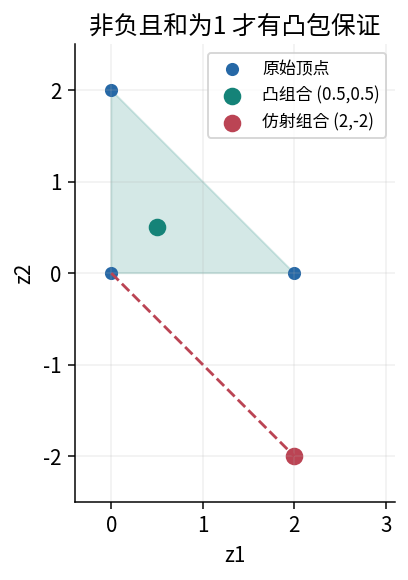

In [4]:
fig, ax = plt.subplots(figsize=(6.6,4.4))
ax.add_patch(Polygon(vertices, closed=True, fc=TEAL, ec=TEAL, alpha=.18))
ax.scatter(*vertices.T, c=BLUE, label="原始顶点")
ax.scatter(*average, c=TEAL, s=70, label="凸组合 (0.5,0.5)")
ax.scatter(*affine_combination, c=RED, s=70, label="仿射组合 (2,-2)")
ax.plot([0,2],[0,-2], "--", color=RED)
ax.set(xlim=(-.4,3.1), ylim=(-2.5,2.5), xlabel="z1", ylabel="z2",
       title="非负且和为1 才有凸包保证")
ax.set_aspect("equal"); ax.grid(alpha=.2); ax.legend(loc="upper right", fontsize=9)
show_png(fig)

### 3 Jensen的正例与反例
`jensen_diagnostic` 只判断指定有限点的比较，不知道函数是否全域凸。标量点写成(m,1)形状。平方函数的差距应为3/2；非凸函数在精心选择的两个点上应违反不等式。

In [5]:
square = lambda point: e.squared_distance(point, [0])
jensen = e.jensen_diagnostic(square, [[1],[2],[4]], [.5,.25,.25])
print("平方函数:", jensen)
nonconvex = e.jensen_diagnostic(lambda point: float(point[0]**4-point[0]**2),
                               [[-1/np.sqrt(2)],[1/np.sqrt(2)]], [.5,.5])
print("非凸反例:", nonconvex)
assert jensen["left"] == 4 and jensen["right"] == 5.5 and jensen["gap"] == 1.5
assert nonconvex["gap"] < 0

平方函数: {'average': [2.0], 'left': 4.0, 'right': 5.5, 'gap': 1.5, 'holds_within_tolerance': True, 'weight_sum': 1.0}
非凸反例: {'average': [0.0], 'left': 0.0, 'right': -0.24999999999999997, 'gap': -0.24999999999999997, 'holds_within_tolerance': False, 'weight_sum': 1.0}


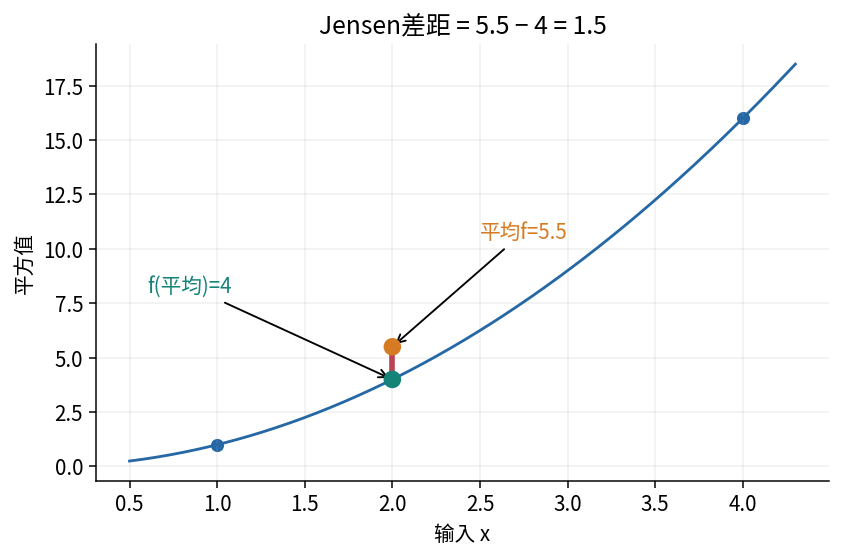

In [6]:
fig, ax = plt.subplots(figsize=(7,4.2))
x = np.linspace(.5,4.3,300)
ax.plot(x,x*x,color=BLUE,label="f(x)=x²")
ax.scatter([1,2,4],[1,4,16],color=BLUE)
ax.scatter([2,2],[jensen["left"],jensen["right"]],color=[TEAL,ORANGE],s=70,zorder=6)
ax.plot([2,2],[4,5.5],color=RED,lw=3)
ax.annotate("f(平均)=4",(2,4),xytext=(.6,8),arrowprops={"arrowstyle":"->"},color=TEAL)
ax.annotate("平均f=5.5",(2,5.5),xytext=(2.5,10.5),arrowprops={"arrowstyle":"->"},color=ORANGE)
ax.set(xlabel="输入 x",ylabel="平方值",title="Jensen差距 = 5.5 − 4 = 1.5")
ax.grid(alpha=.2)
show_png(fig)

### 4 三种集合 同一个建议点
先对每个候选核对可行性，再比较平方距离。半平方目标是距离平方的一半；不要把两种列名混用。

In [7]:
p_box = e.project_box(v,[0,0],[2,1])
p_ball = e.project_ball(v,[0,0],2)
p_line = e.project_hyperplane(v,[1,1],1)
for name, p in [("box",p_box),("ball",p_ball),("line",p_line)]:
    print(name, "p =", np.round(p,9), "distance² =", e.squared_distance(v,p))
assert np.all((p_box >= [0,0]) & (p_box <= [2,1]))
assert np.linalg.norm(p_ball) <= 2+e.ATOL
assert abs(p_line.sum()-1) <= e.ATOL

box p = [2. 1.] distance² = 2.0
ball p = [1.66410059 1.10940039] distance² = 2.5777948981440426
line p = [1. 0.] distance² = 8.0


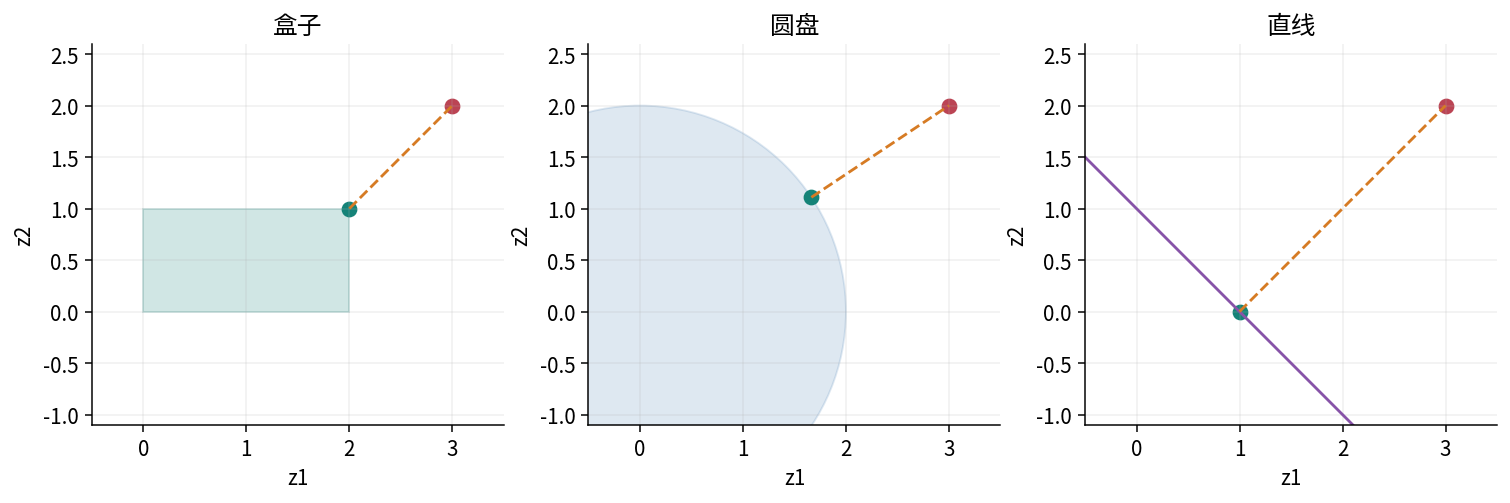

In [8]:
fig, axes = plt.subplots(1,3,figsize=(11.2,3.6))
for ax, name, p in zip(axes,["盒子","圆盘","直线"],[p_box,p_ball,p_line]):
    if name == "盒子":
        ax.add_patch(Rectangle((0,0),2,1,fc=TEAL,ec=TEAL,alpha=.2))
    elif name == "圆盘":
        ax.add_patch(Circle((0,0),2,fc=BLUE,ec=BLUE,alpha=.15))
    else:
        t = np.linspace(-1,3,60); ax.plot(t,1-t,color=PURPLE)
    ax.plot([p[0],v[0]],[p[1],v[1]],"--",color=ORANGE)
    ax.scatter(*v,color=RED,s=55); ax.scatter(*p,color=TEAL,s=55)
    ax.set(xlim=(-.5,3.5),ylim=(-1.1,2.6),xlabel="z1",ylabel="z2",title=name)
    ax.set_aspect("equal"); ax.grid(alpha=.2)
fig.tight_layout(); show_png(fig)

### 5 内部点 球中心 零半径与半空间
合法内部点不应该被人为推到边界。对半空间先判断不等式；对等式集则无论原点是否靠近边界，都必须满足等式。

In [9]:
print("球内保持:", e.project_ball([.5,.5],[0,0],2))
print("球中心:", e.project_ball([1,-1],[1,-1],2))
print("零半径:", e.project_ball([4,3],[1,-1],0))
shifted = e.project_ball([4,3],[1,-1],2)
print("平移球:", shifted, "distance² =", e.squared_distance([4,3],shifted))
print("半空间内部:", e.project_halfspace([0,0],[1,1],1))
print("同样输入到等式:", e.project_hyperplane([0,0],[1,1],1))
print("区间端点与内部:", [e.project_interval(x,0,1) for x in [-2,0,.4,1,3]])

球内保持: [0.5 0.5]
球中心: [ 1. -1.]
零半径: [ 1. -1.]
平移球: [2.2 0.6] distance² = 8.999999999999998
半空间内部: [0. 0.]
同样输入到等式: [0.5 0.5]
区间端点与内部: [0.0, 0.0, 0.4, 1.0, 1.0]


### 6 三维仿射线与最小范数修正
A为2×3，等式独立。`project_affine`显式检查最终约束残差；`lstsq`的空残差数组不能当成可行证书。此接口拒绝数值缺行秩的方程组，包括一致的冗余组。

沿d=(1,-1,1)写可行点p+td，应得到距离平方26/3+3t²。

In [10]:
v3 = np.array([3.,2.,1.])
p3 = e.project_affine(v3,A,b)
direction = np.array([1.,-1.,1.])
steps = np.linspace(-2,2,81)
affine_points, distances = e.line_samples(lambda z: e.squared_distance(v3,z), p3, direction, steps)
print("p =", p3, "A@p-b =", A@p3-b)
print("residual dot direction =", np.dot(v3-p3,direction))
print("distance² =", e.squared_distance(v3,p3), "; analytic =", 26/3)
assert np.allclose(distances,26/3+3*steps**2,rtol=0,atol=e.ATOL)
assert np.max(abs(affine_points@A.T-b)) <= e.ATOL
print("独立分数核验:", e.fraction_checks())

p = [ 1.33333333 -0.33333333  0.33333333] A@p-b = [-1.77635684e-15 -1.99840144e-15]
residual dot direction = -6.661338147750939e-16
distance² = 8.666666666666675 ; analytic = 8.666666666666666
独立分数核验: {'box': ['2', '1'], 'line': ['1', '0'], 'affine': ['4/3', '-1/3', '1/3'], 'affine_squared_distance': '26/3', 'affine_residual_dot_null_direction': '0', 'jensen_mean': '2', 'jensen_left': '4', 'jensen_right': '11/2', 'jensen_gap': '3/2'}


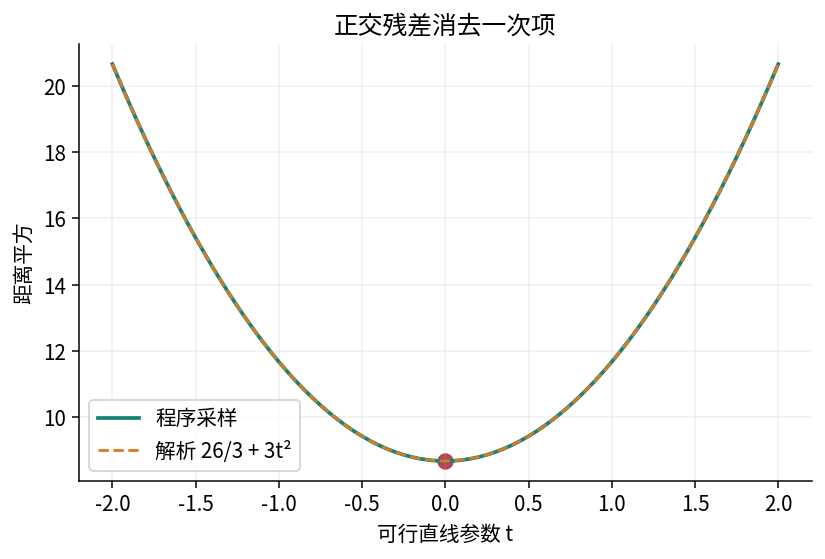

In [11]:
fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(steps,distances,color=TEAL,lw=2,label="程序采样")
ax.plot(steps,26/3+3*steps**2,"--",color=ORANGE,label="解析 26/3 + 3t²")
ax.scatter(0,26/3,color=RED,s=60)
ax.set(xlabel="可行直线参数 t",ylabel="距离平方",title="正交残差消去一次项")
ax.legend(); ax.grid(alpha=.2); show_png(fig)

### 7 单次顺序投影陷阱
先盒后球与先球后盒都可行，但不等于交集投影。真投影p=(√3,1)的证明依靠对全部可行z成立的两个几何不等式，详见正文。这里先比较计算结果，再用p对错误候选做反例测试。

In [12]:
p_true = np.array([np.sqrt(3),1.])
q_box_ball = e.project_ball(p_box,[0,0],2)
q_ball_box = e.project_box(p_ball,[0,0],[2,1])
intersection_names = ["真投影","先盒后球","先球后盒"]
intersection_points = [p_true,q_box_ball,q_ball_box]
intersection_distances = []
for name, q in zip(intersection_names,intersection_points):
    assert np.all(q >= 0) and np.all(q <= [2,1]) and np.linalg.norm(q) <= 2+e.ATOL
    d2 = e.squared_distance(v,q); intersection_distances.append(d2)
    counter = float(e.certificate_values(v,q,[p_true])[0])
    print(name, np.round(q,9), "distance² =", round(d2,9), "证书在p处 =", round(counter,9))
assert np.allclose(v-p_true,(np.sqrt(3)-1)*p_true+(2-np.sqrt(3))*np.array([0,1]),rtol=0,atol=e.ATOL)
print("真投影残差的两个非负系数:", np.sqrt(3)-1, 2-np.sqrt(3))

真投影 [1.73205081 1.        ] distance² = 2.607695155 证书在p处 = 0.0
先盒后球 [1.78885438 0.89442719] distance² = 2.689164944 证书在p处 = 0.047921027
先球后盒 [1.66410059 1.        ] distance² = 2.784627237 证书在p处 = 0.090774657
真投影残差的两个非负系数: 0.7320508075688772 0.2679491924311228


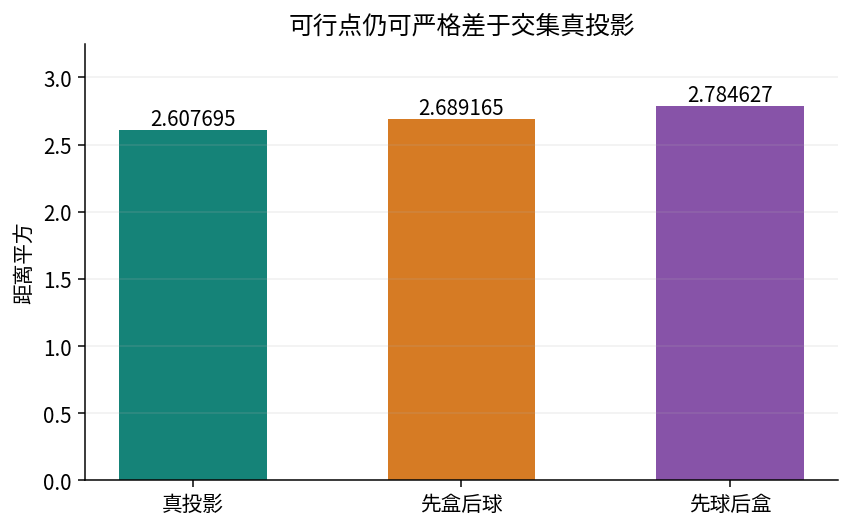

In [13]:
fig, ax = plt.subplots(figsize=(7.2,4.2))
ax.bar(intersection_names,intersection_distances,color=[TEAL,ORANGE,PURPLE],width=.55)
for i, value in enumerate(intersection_distances):
    ax.text(i,value+.04,f"{value:.6f}",ha="center")
ax.set(ylim=(0,3.25),ylabel="距离平方",title="可行点仍可严格差于交集真投影")
ax.grid(axis="y",alpha=.2); show_png(fig)

### 8 非扩张只比较同一个映射
对四种投影各比较固定四点的16个有序对。下面显示的64个有限差值应不为正。一般结论需由两条投影证书相加证明；若集合改变，相互代入候选点的步骤可能不合法。

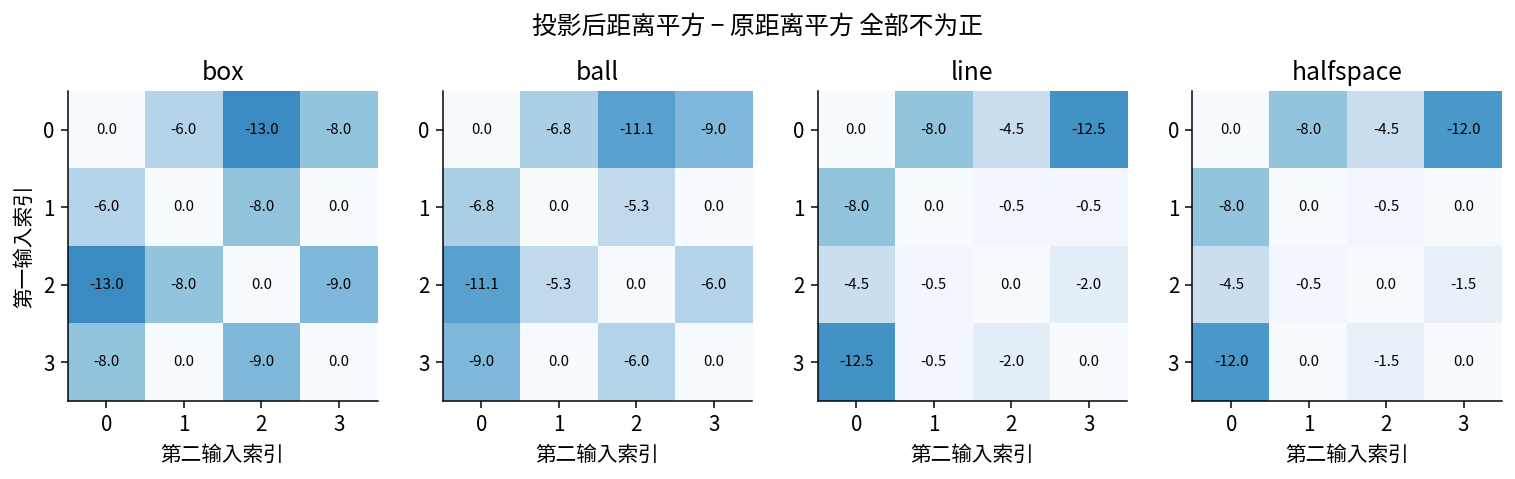

In [14]:
projectors = {"box":lambda z:e.project_box(z,[0,0],[2,1]),
              "ball":lambda z:e.project_ball(z,[0,0],2),
              "line":lambda z:e.project_hyperplane(z,[1,1],1),
              "halfspace":lambda z:e.project_halfspace(z,[1,1],1)}
fig, axes = plt.subplots(1,4,figsize=(11.5,3.2))
for ax, (name, projector) in zip(axes,projectors.items()):
    differences = np.array([[e.squared_distance(projector(x),projector(y))-e.squared_distance(x,y)
                             for y in points] for x in points])
    assert np.max(differences) <= e.ATOL
    im = ax.imshow(differences,cmap="Blues_r",vmin=-20,vmax=0)
    ax.set_title(name); ax.set_xticks(range(4),range(4)); ax.set_yticks(range(4),range(4))
    ax.set_xlabel("第二输入索引")
    for (i,j), value in np.ndenumerate(differences):
        ax.text(j,i,f"{value:.1f}",ha="center",va="center",fontsize=8,color="black")
axes[0].set_ylabel("第一输入索引")
fig.suptitle("投影后距离平方 − 原距离平方 全部不为正",y=1.02)
fig.tight_layout(); show_png(fig)

## 检查
### 9 故意失败也要给清楚理由
输入类型、形状与有限性在计算之前检查；中间采样点在回调之前检查；回调返回值仍需检查。有限输入不保证乘加、平方、范数也有限。极端尺度会明确拒绝，不宣称是通用稳定求解器。

In [15]:
boundaries = e.boundary_checks()
rejected = [row for row in boundaries if row["status"] == "rejected_as_expected"]
accepted = [row for row in boundaries if row["status"] == "accepted_as_expected"]
print("边界总数:",len(boundaries),"; 正确拒绝:",len(rejected),"; 合法边界:",len(accepted))
for wanted in ["weights_negative","affine_inconsistent_rows","ball_norm_overflow",
               "line_nonfinite_samples_before_callback","jensen_nonfinite_mean_before_callback"]:
    print(next(row for row in boundaries if row["case"] == wanted))
print("合法边界:",[row["case"] for row in accepted])

边界总数: 71 ; 正确拒绝: 61 ; 合法边界: 10
{'case': 'weights_negative', 'status': 'rejected_as_expected', 'message': '凸组合权重不能为负'}
{'case': 'affine_inconsistent_rows', 'status': 'rejected_as_expected', 'message': 'matrix 不是数值满行秩；本接口拒绝冗余或矛盾等式'}
{'case': 'ball_norm_overflow', 'status': 'rejected_as_expected', 'message': 'project_ball 超出本教学实现的有限数值范围'}
{'case': 'line_nonfinite_samples_before_callback', 'status': 'rejected_as_expected', 'message': 'line_samples 超出本教学实现的有限数值范围'}
{'case': 'jensen_nonfinite_mean_before_callback', 'status': 'rejected_as_expected', 'message': 'convex_combination 超出本教学实现的有限数值范围'}
合法边界: ['interval_singleton', 'box_singleton_coordinate', 'ball_inside', 'ball_center', 'ball_zero_radius', 'halfspace_inside', 'halfspace_boundary', 'one_weight', 'zero_weight', 'zero_direction']


### 10 汇总并读有限网格检查
网格最小距离可略大于解析最小值，因为网格未必包含精确答案。投影证书对有限候选成立是实现检查；正文的代数与几何论证才覆盖整个集合。

In [16]:
report = e.run_experiment(write_outputs=True)
print("脚本完整验收通过，投影案例数:",report["projection_case_count"])
for diagnostic in report["finite_grid_diagnostics"]:
    print(diagnostic)
assert len(report["boundary_checks"]) == 71
print("可再生成结果已写入 outputs/。")

脚本完整验收通过，投影案例数: 16
{'set': 'box', 'candidate_count': 10201, 'max_certificate_inner_product': 0.0, 'grid_best_minus_analytic_d2': 0.0}
{'set': 'ball', 'candidate_count': 2541, 'max_certificate_inner_product': -0.00023289322025256604, 'grid_best_minus_analytic_d2': 0.001046006390652554}
{'set': 'hyperplane', 'candidate_count': 121, 'max_certificate_inner_product': 0.0, 'grid_best_minus_analytic_d2': 0.0}
{'set': 'halfspace', 'candidate_count': 1331, 'max_certificate_inner_product': 0.0, 'grid_best_minus_analytic_d2': 0.0}
{'set': 'intersection', 'candidate_count': 9705, 'max_certificate_inner_product': -0.009920827876478272, 'grid_best_minus_analytic_d2': 0.020304845413263717}
可再生成结果已写入 outputs/。


## 小结与下一步
实际输出为：盒子投影(2,1)，圆盘投影约(1.664101,1.109400)，直线投影(1,0)；Jensen差距1.5；三维仿射平方距离26/3。交集真投影的距离平方约2.607695，小于两种单次顺序投影的2.689165与2.784627。

这些数值与正文手算一致。严格凸保证至多一个最优点；非空闭凸集合与连续平方距离进一步给出存在性。边界最优不需要梯度为零，但需要沿所有可行方向满足一阶条件。

练习：给零半径球、冗余方程组、含负权重的组合分别写出数学解释与接口行为；推导投影非扩张性，标明两次投影使用同一个集合的那一步。

本Notebook已由新Python进程中的真实ipykernel InProcessKernel顺序执行并保留PNG输出；构建环境socket传输不可用，因此未测试外进程socket、Jupyter浏览器界面或读者本机Anaconda。复现时请重启内核并运行全部单元。

来源与条件核验见 `source-checks.json`；官方接口：[NumPy clip](https://numpy.org/doc/2.3/reference/generated/numpy.clip.html)、[NumPy lstsq](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.lstsq.html)。